In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('500hits.csv' , encoding='latin-1')

In [3]:
df.head()

,PLAYER,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA,HOF
0,Ty Cobb,24,3035,11434,2246,4189,724,295,117,726,1249,357,892,178,0.366,1
1,Stan Musial,22,3026,10972,1949,3630,725,177,475,1951,1599,696,78,31,0.331,1
2,Tris Speaker,22,2789,10195,1882,3514,792,222,117,724,1381,220,432,129,0.345,1
3,Derek Jeter,20,2747,11195,1923,3465,544,66,260,1311,1082,1840,358,97,0.310,1
4,Honus Wagner,21,2792,10430,1736,3430,640,252,101,0,963,327,722,15,0.329,1


In [4]:
df = df.drop(columns = ['PLAYER', 'CS'])

In [5]:
X = df.iloc[:, 0:13]

In [6]:
y = df.iloc[:,13]

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=17, test_size=0.2)

In [9]:
X_train.shape

(372, 13)

In [10]:
X_test.shape

(93, 13)

In [11]:
from sklearn.tree import DecisionTreeClassifier 

In [12]:
dtc = DecisionTreeClassifier()

In [13]:
dtc.get_params(deep=True)

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [14]:
dtc.fit(X_train, y_train)


DecisionTreeClassifier()

[Text(0.6621621621621622, 0.9642857142857143, 'x[4] <= 2282.5\ngini = 0.439\nsamples = 372\nvalue = [252.0, 119.0, 1.0]'),
 Text(0.46621621621621623, 0.8928571428571429, 'x[12] <= 0.311\ngini = 0.242\nsamples = 255\nvalue = [219, 36, 0]'),
 Text(0.5641891891891893, 0.9285714285714286, 'True  '),
 Text(0.39864864864864863, 0.8214285714285714, 'x[7] <= 420.5\ngini = 0.192\nsamples = 242\nvalue = [216, 26, 0]'),
 Text(0.34459459459459457, 0.75, 'x[3] <= 626.0\ngini = 0.162\nsamples = 236\nvalue = [215, 21, 0]'),
 Text(0.31756756756756754, 0.6785714285714286, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.3716216216216216, 0.6785714285714286, 'x[5] <= 508.5\ngini = 0.156\nsamples = 235\nvalue = [215, 20, 0]'),
 Text(0.34459459459459457, 0.6071428571428571, 'x[6] <= 61.5\ngini = 0.149\nsamples = 234\nvalue = [215, 19, 0]'),
 Text(0.20270270270270271, 0.5357142857142857, 'x[8] <= 1396.5\ngini = 0.049\nsamples = 120\nvalue = [117, 3, 0]'),
 Text(0.13513513513513514, 0.4642857142857143

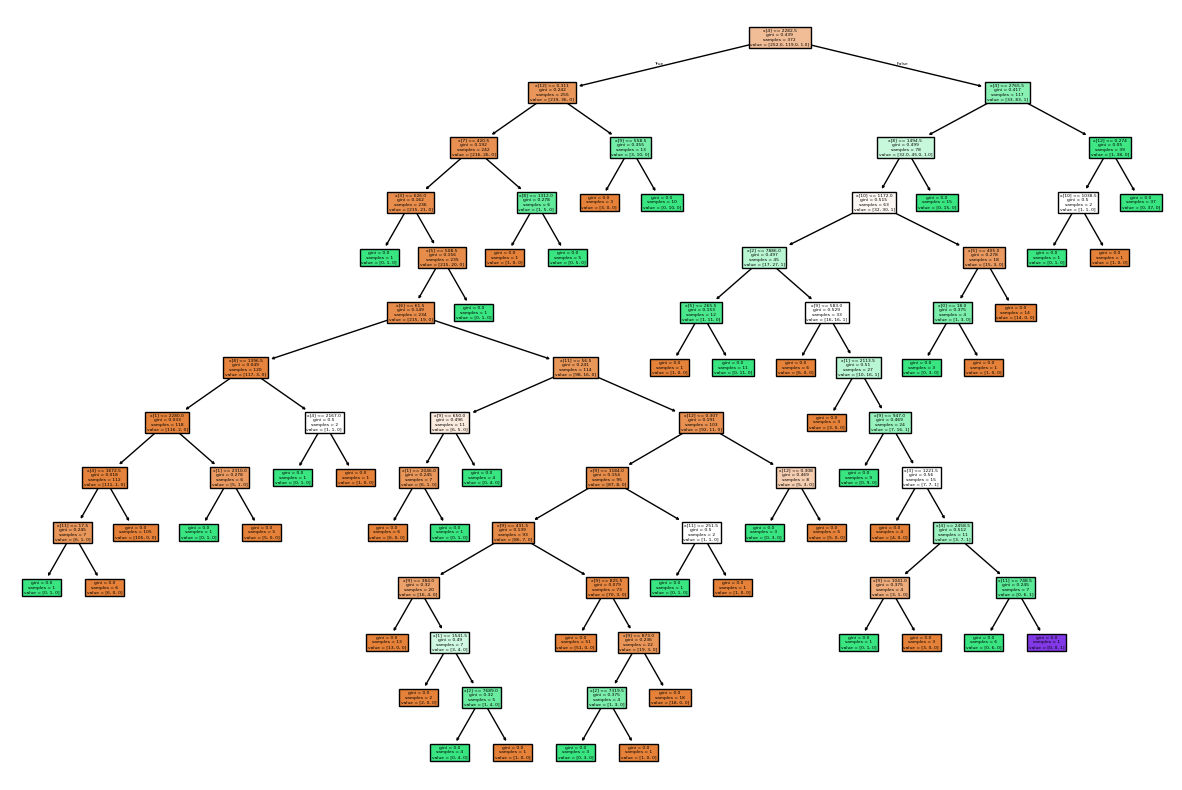

In [32]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dtc,filled=True)

In [15]:
y_pred = dtc.predict(X_test)

In [16]:
from sklearn.metrics import confusion_matrix

In [17]:
print(confusion_matrix(y_test, y_pred))

[[49 12]
 [11 21]]


In [18]:
from sklearn.metrics import classification_report

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        61
           1       0.64      0.66      0.65        32

    accuracy                           0.75        93
   macro avg       0.73      0.73      0.73        93
weighted avg       0.75      0.75      0.75        93



In [20]:
dtc.feature_importances_

array([0.00919003, 0.04914027, 0.03778741, 0.02714491, 0.39351028,
       0.04297592, 0.00953164, 0.03972447, 0.05536963, 0.15381942,
       0.0373047 , 0.04185942, 0.10264192])

In [21]:
features = pd.DataFrame(dtc.feature_importances_, index = X.columns)

In [22]:
features.head(15)

,0
YRS,0.009190
G,0.049140
AB,0.037787
R,0.027145
H,0.393510
2B,0.042976
3B,0.009532
HR,0.039724
RBI,0.055370
BB,0.153819


In [23]:
dtc2 = DecisionTreeClassifier(criterion='entropy', ccp_alpha= 0.04)
#ccp_alpha helps in preventing overfiting

In [24]:
dtc2.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.04, criterion='entropy')

In [25]:
y_pred2 = dtc2.predict(X_test)

In [26]:
print(confusion_matrix(y_test, y_pred2))

[[50 11]
 [ 9 23]]


In [27]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83        61
           1       0.68      0.72      0.70        32

    accuracy                           0.78        93
   macro avg       0.76      0.77      0.77        93
weighted avg       0.79      0.78      0.79        93



In [28]:
features2 = pd.DataFrame(dtc2.feature_importances_, index = X.columns)

In [29]:
features2.head(15)

,0
YRS,0.000000
G,0.000000
AB,0.000000
R,0.000000
H,0.837977
2B,0.000000
3B,0.000000
HR,0.000000
RBI,0.000000
BB,0.000000


#gini impurity
The formula to calculate Gini Impurity for a node is:
gini=1-summation(i=1 to c)(pi)^2
Where:
C is the number of total classes in your target variable (e.g., "Yes"/"No", "Dog"/"Cat"/"Bird").
p_i is the probability (proportion) of picking a data point of class i in that node.

1.Pure Bag (All Red Marbles):
p_{red} = 1
p_{blue} = 0
Gini = 1 - (1^2 + 0^2) = 1 - (1 + 0) = 0

2.Perfectly Mixed Bag (5 Red, 5 Blue):
p_{red} = 5/10 = 0.5
p_{blue} = 5/10 = 0.5
Gini = 1 - (0.5^2 + 0.5^2) = 1 - (0.25 + 0.25) = 1 - 0.5 = 0.5

This is the highest possible impurity for a two-class problem
3.Another Example (7 Red, 3 Blue):
p_{red} = 0.7
p_{blue} = 0.3
Gini = 1 - (0.7^2 + 0.3^2) = 1 - (0.49 + 0.09) = 1 - 0.58 = 0.42
As you can see, the impurity decreases as the bag becomes more pure (dominated by one class).

In the context of a Decision Tree, Gini Impurity measures how often a randomly chosen data point from a node (a group of data) would be incorrectly labeled if it were randomly labeled according to the class distribution of the node.

A lower Gini Impurity means a more homogeneous (pure) node.

The goal of a Decision Tree is to split the data into the purest possible subgroups (leaves